# =====================================================

# IPL STATISTICS ANALYSIS PROJECT
# Author: Mukto Seikh
# Objective:
# Perform Statistical Analysis and Exploratory Data Analysis
# on IPL Match and Ball-by-Ball Data

# =====================================================


# IMPORT REQUIRED LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# =====================================================

# LOAD DATASETS

In [2]:
matches = pd.read_csv("IPL Matches.csv")
deliveries = pd.read_csv("IPL Ball-by-Ball.csv")

# =====================================================

# DATA CLEANING

In [3]:
matches.drop_duplicates(inplace=True)
deliveries.drop_duplicates(inplace=True)

matches["date"] = pd.to_datetime(matches["date"])

print("Duplicates Removed Successfully")

Duplicates Removed Successfully


# =====================================================

# DATA OVERVIEW

In [4]:

print("="*60)
print("MATCHES DATASET")
print("="*60)

print(matches.head())
print("\nShape:", matches.shape)

print("\n" + "="*60)
print("DELIVERIES DATASET")
print("="*60)

print(deliveries.head())
print("\nShape:", deliveries.shape)

# Insight:
# The matches dataset contains match-level information,
# while the deliveries dataset contains ball-by-ball records.

MATCHES DATASET
       id        city       date player_of_match  \
0  335982   Bangalore 2008-04-18     BB McCullum   
1  335983  Chandigarh 2008-04-19      MEK Hussey   
2  335984       Delhi 2008-04-19     MF Maharoof   
3  335985      Mumbai 2008-04-20      MV Boucher   
4  335986     Kolkata 2008-04-20       DJ Hussey   

                                        venue  neutral_venue  \
0                       M Chinnaswamy Stadium              0   
1  Punjab Cricket Association Stadium, Mohali              0   
2                            Feroz Shah Kotla              0   
3                            Wankhede Stadium              0   
4                                Eden Gardens              0   

                         team1                        team2  \
0  Royal Challengers Bangalore        Kolkata Knight Riders   
1              Kings XI Punjab          Chennai Super Kings   
2             Delhi Daredevils             Rajasthan Royals   
3               Mumbai Indians  Ro

### Insight:
### The matches dataset contains match-level information,
### while the deliveries dataset contains ball-by-ball records.

# =====================================================

# DATASET INFORMATION

In [5]:
print("\nMATCHES INFO")
print(matches.info())

print("\nDELIVERIES INFO")
print(deliveries.info())


MATCHES INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               816 non-null    int64         
 1   city             803 non-null    object        
 2   date             816 non-null    datetime64[ns]
 3   player_of_match  812 non-null    object        
 4   venue            816 non-null    object        
 5   neutral_venue    816 non-null    int64         
 6   team1            816 non-null    object        
 7   team2            816 non-null    object        
 8   toss_winner      816 non-null    object        
 9   toss_decision    816 non-null    object        
 10  winner           812 non-null    object        
 11  result           812 non-null    object        
 12  result_margin    799 non-null    float64       
 13  eliminator       812 non-null    object        
 14  method           19 non-null

# =====================================================

# CHECK MISSING VALUES

In [6]:
print("\nMISSING VALUES - MATCHES")
print(matches.isnull().sum())

print("\nMISSING VALUES - DELIVERIES")
print(deliveries.isnull().sum())




MISSING VALUES - MATCHES
id                   0
city                13
date                 0
player_of_match      4
venue                0
neutral_venue        0
team1                0
team2                0
toss_winner          0
toss_decision        0
winner               4
result               4
result_margin       17
eliminator           4
method             797
umpire1              0
umpire2              0
dtype: int64

MISSING VALUES - DELIVERIES
id                       0
inning                   0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
batsman_runs             0
extra_runs               0
total_runs               0
non_boundary             0
is_wicket                0
dismissal_kind      183972
player_dismissed    183972
fielder             186683
extras_type         183234
batting_team             0
bowling_team           191
dtype: int64


### Insight:
### Missing values are present in some columns
### and should be handled before advanced modeling.

# =====================================================

# DESCRIPTIVE STATISTICS

In [7]:
print("\nSTATISTICAL SUMMARY - MATCHES")
print(matches.describe())

print("\nSTATISTICAL SUMMARY - DELIVERIES")
print(deliveries.describe())




STATISTICAL SUMMARY - MATCHES
                 id                           date  neutral_venue  \
count  8.160000e+02                            816     816.000000   
mean   7.563496e+05  2014-04-13 19:07:03.529411840       0.094363   
min    3.359820e+05            2008-04-18 00:00:00       0.000000   
25%    5.012278e+05            2011-04-26 18:00:00       0.000000   
50%    7.292980e+05            2014-04-23 12:00:00       0.000000   
75%    1.082626e+06            2017-04-30 00:00:00       0.000000   
max    1.237181e+06            2020-11-10 00:00:00       1.000000   
std    3.058943e+05                            NaN       0.292512   

       result_margin  
count     799.000000  
mean       17.321652  
min         1.000000  
25%         6.000000  
50%         8.000000  
75%        19.500000  
max       146.000000  
std        22.068427  

STATISTICAL SUMMARY - DELIVERIES
                 id         inning           over           ball  \
count  1.934670e+05  193467.000000  19

### Insight:
### Descriptive statistics provide an overview
### of the numerical features in the datasets.

# =====================================================

# MEAN, MEDIAN, MODE

In [8]:
print("\nMEAN RUNS PER BALL")
print(deliveries["total_runs"].mean())

print("\nMEDIAN RUNS PER BALL")
print(deliveries["total_runs"].median())

print("\nMODE RUNS PER BALL")
print(deliveries["total_runs"].mode())




MEAN RUNS PER BALL
1.3066466115668305

MEDIAN RUNS PER BALL
1.0

MODE RUNS PER BALL
0    1
Name: total_runs, dtype: int64


### Insight:
### Most deliveries result in low scores,
### indicating singles and dot balls dominate IPL matches

# =====================================================

# VARIANCE & STANDARD DEVIATION

In [9]:
print("\nVARIANCE")
print(deliveries["total_runs"].var())

print("\nSTANDARD DEVIATION")
print(deliveries["total_runs"].std())



VARIANCE
2.556179810011903

STANDARD DEVIATION
1.5988057449271011


### Insight:
### Variance and standard deviation measure
### scoring variability across deliveries.


# =====================================================

# RUNS DISTRIBUTION

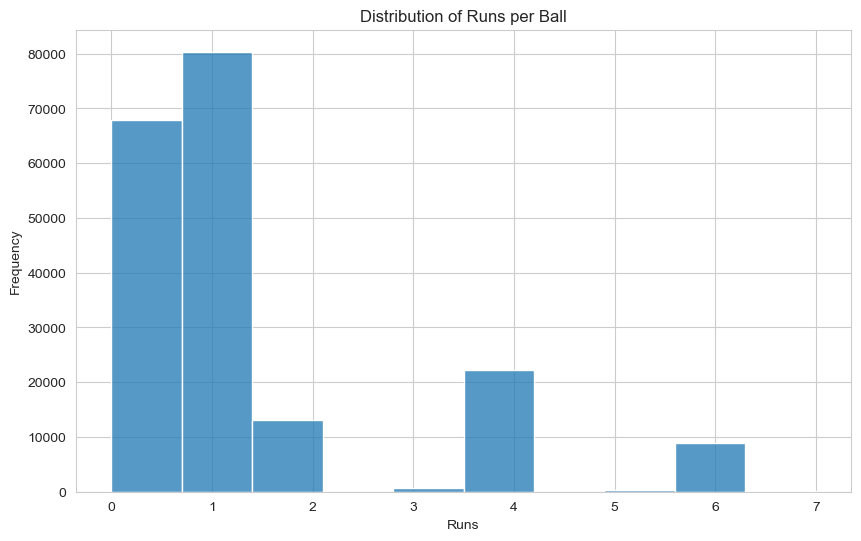

In [10]:

plt.figure(figsize=(10,6))
sns.histplot(deliveries["total_runs"], bins=10)
plt.title("Distribution of Runs per Ball")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()



### Insight:
### Most balls produce 0–1 runs,
### while boundaries occur less frequently.

# =====================================================

# TOP 10 BATSMEN


TOP 10 BATSMEN
batsman
V Kohli           5878
SK Raina          5368
DA Warner         5254
RG Sharma         5230
S Dhawan          5197
AB de Villiers    4849
CH Gayle          4772
MS Dhoni          4632
RV Uthappa        4607
G Gambhir         4217
Name: batsman_runs, dtype: int64


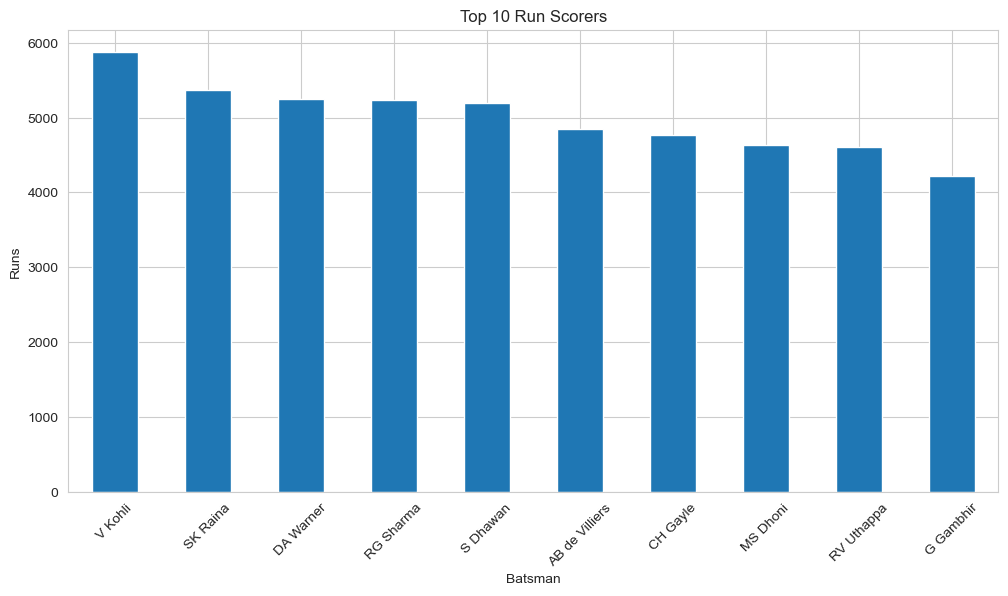

In [11]:
top_batsmen = (
    deliveries.groupby("batsman")["batsman_runs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTOP 10 BATSMEN")
print(top_batsmen)

plt.figure(figsize=(12,6))
top_batsmen.plot(kind="bar",figsize=(12,6))
plt.xticks(rotation=45)
plt.title("Top 10 Run Scorers")
plt.xlabel("Batsman")
plt.ylabel("Runs")
plt.show()


### Insight:
### These batsmen consistently scored
### the highest runs across IPL seasons.

# =====================================================

# TOP 10 BOWLERS


TOP 10 BOWLERS
bowler
SL Malinga         188
DJ Bravo           175
A Mishra           169
PP Chawla          164
Harbhajan Singh    161
R Ashwin           153
B Kumar            146
SP Narine          143
UT Yadav           137
R Vinay Kumar      127
Name: is_wicket, dtype: int64


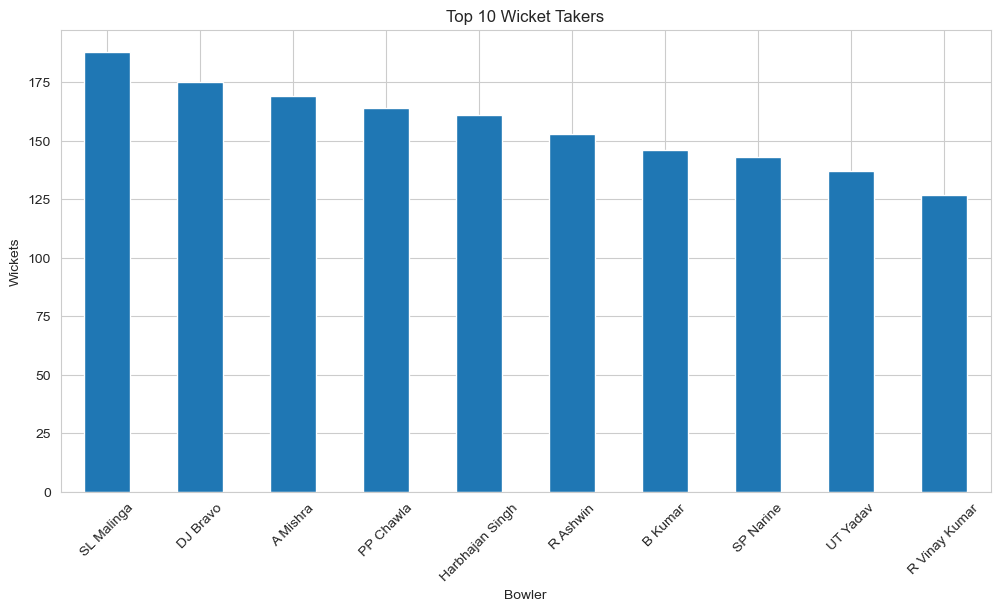

In [12]:
top_bowlers = (
    deliveries[deliveries["is_wicket"] == 1]
    .groupby("bowler")["is_wicket"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTOP 10 BOWLERS")
print(top_bowlers)

plt.figure(figsize=(12,6))
top_bowlers.plot(kind="bar")
plt.xticks(rotation=45)
plt.title("Top 10 Wicket Takers")
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.show()


### Insight:
### These bowlers have taken the most wickets
### in IPL history.

# =====================================================

# TEAM WIN ANALYSIS


TEAM WINS
winner
Mumbai Indians                 120
Chennai Super Kings            106
Kolkata Knight Riders           99
Royal Challengers Bangalore     91
Kings XI Punjab                 88
Rajasthan Royals                81
Delhi Daredevils                67
Sunrisers Hyderabad             66
Deccan Chargers                 29
Delhi Capitals                  19
Name: count, dtype: int64


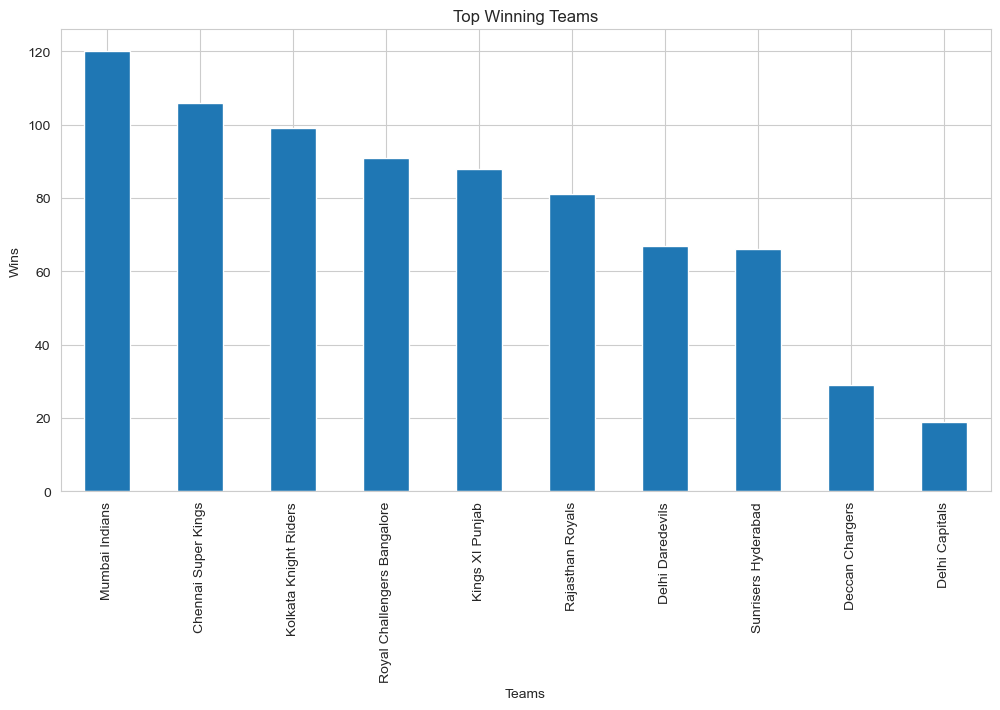

In [13]:

team_wins = matches["winner"].value_counts().head(10)

print("\nTEAM WINS")
print(team_wins)

plt.figure(figsize=(12,6))
team_wins.plot(kind="bar")
plt.title("Top Winning Teams")
plt.xlabel("Teams")
plt.ylabel("Wins")
plt.show()




### Insight:
### Certain teams have dominated the IPL
### through consistent performance.

# =====================================================

# PLAYER OF THE MATCH ANALYSIS


TOP PLAYER OF THE MATCH WINNERS
player_of_match
AB de Villiers    23
CH Gayle          22
RG Sharma         18
DA Warner         17
MS Dhoni          17
SR Watson         16
YK Pathan         16
SK Raina          14
V Kohli           13
G Gambhir         13
Name: count, dtype: int64


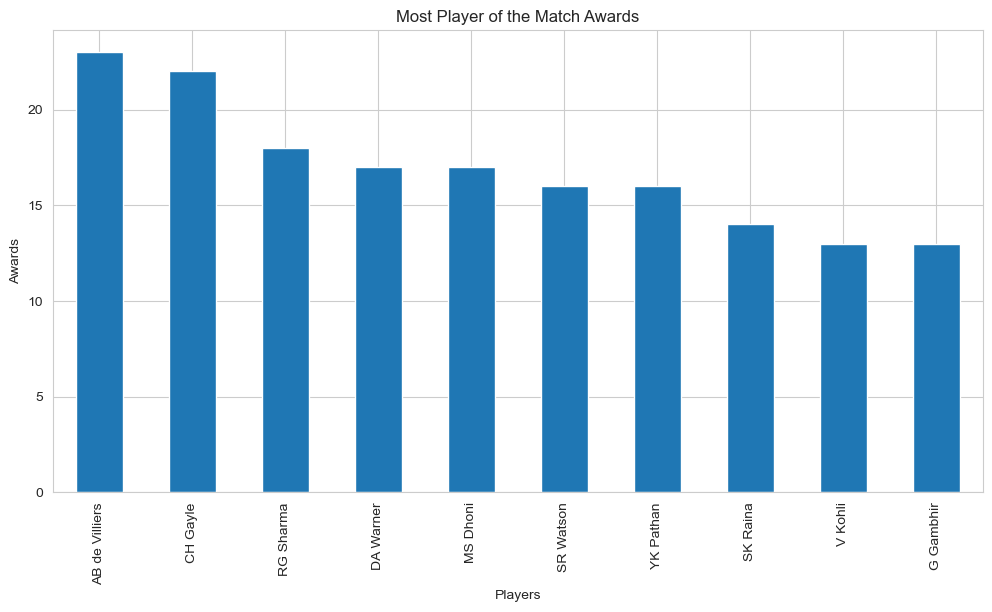

In [14]:
pom = matches["player_of_match"].value_counts().head(10)

print("\nTOP PLAYER OF THE MATCH WINNERS")
print(pom)

plt.figure(figsize=(12,6))
pom.plot(kind="bar")
plt.title("Most Player of the Match Awards")
plt.xlabel("Players")
plt.ylabel("Awards")
plt.show()


### Insight:
### Frequent award winners have delivered
### outstanding performances across seasons.

# =====================================================

# TOSS IMPACT ANALYSIS

In [15]:
toss_match_win = matches[
    matches["toss_winner"] == matches["winner"]
]

percentage = (len(toss_match_win) / len(matches)) * 100

print("\nTOSS WIN TO MATCH WIN PERCENTAGE")
print(round(percentage,2), "%")



TOSS WIN TO MATCH WIN PERCENTAGE
51.23 %


### Insight:
### Toss can provide an advantage,
### but does not guarantee victory.

# =====================================================

# TOP IPL VENUES


TOP VENUES
venue
Eden Gardens                                  77
Feroz Shah Kotla                              74
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Rajiv Gandhi International Stadium, Uppal     64
MA Chidambaram Stadium, Chepauk               57
Sawai Mansingh Stadium                        47
Punjab Cricket Association Stadium, Mohali    35
Dubai International Cricket Stadium           33
Sheikh Zayed Stadium                          29
Name: count, dtype: int64


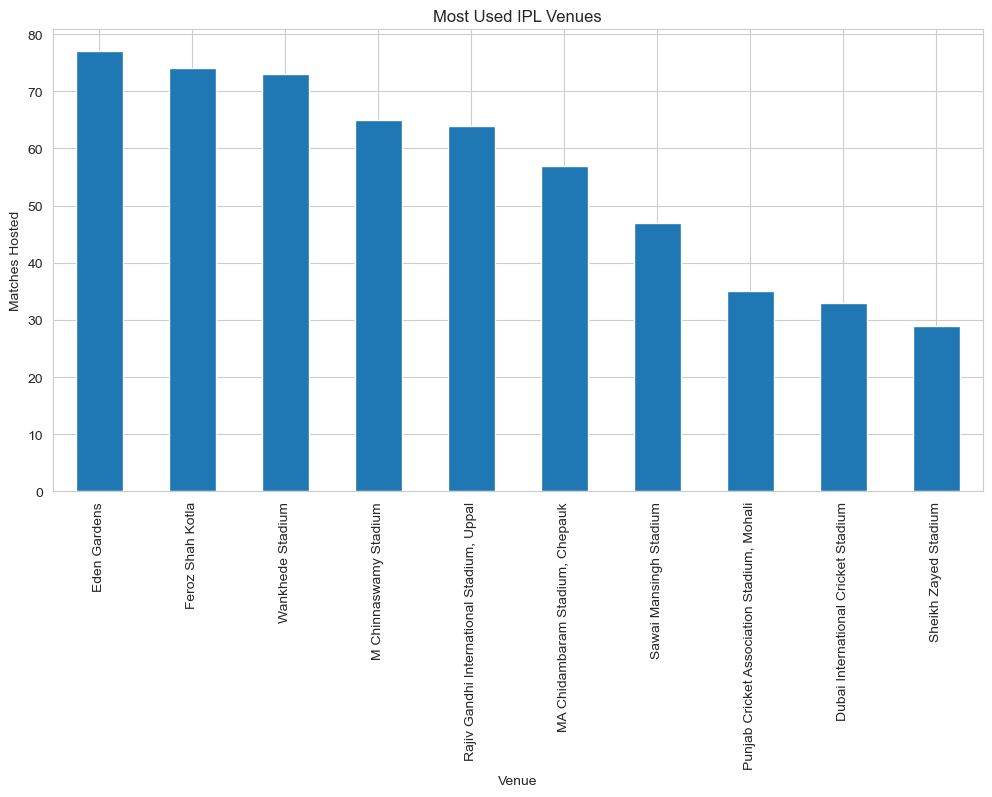

In [16]:
venues = matches["venue"].value_counts().head(10)

print("\nTOP VENUES")
print(venues)

plt.figure(figsize=(12,6))
venues.plot(kind="bar")
plt.title("Most Used IPL Venues")
plt.xlabel("Venue")
plt.ylabel("Matches Hosted")
plt.show()



### Insight:
### Some venues host significantly more
### matches than others.

# =====================================================

# TOSS DECISION ANALYSIS


TOSS DECISION
toss_decision
field    496
bat      320
Name: count, dtype: int64


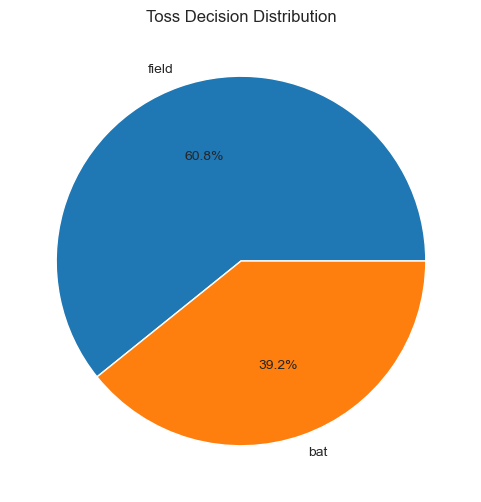

In [17]:

toss_decision = matches["toss_decision"].value_counts()

print("\nTOSS DECISION")
print(toss_decision)

plt.figure(figsize=(6,6))
plt.pie(
    toss_decision,
    labels=toss_decision.index,
    autopct="%1.1f%%"
)
plt.title("Toss Decision Distribution")
plt.show()


# Insight:
# Teams often prefer either batting first
# or chasing depending on conditions.

# =====================================================

# TEAM PARTICIPATION ANALYSIS

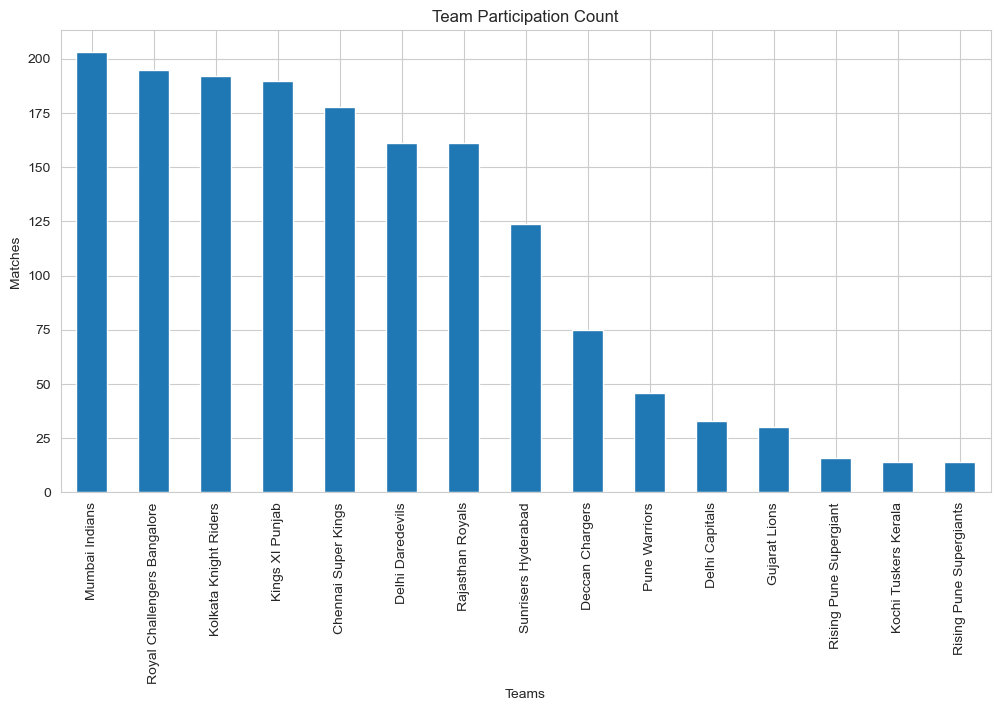

In [18]:
teams = pd.concat(
    [matches["team1"], matches["team2"]]
)

team_count = teams.value_counts()

plt.figure(figsize=(12,6))
team_count.plot(kind="bar")
plt.title("Team Participation Count")
plt.xlabel("Teams")
plt.ylabel("Matches")
plt.show()


### Insight:
### This chart shows the participation
### frequency of IPL franchises.


# =====================================================

# CORRELATION ANALYSIS

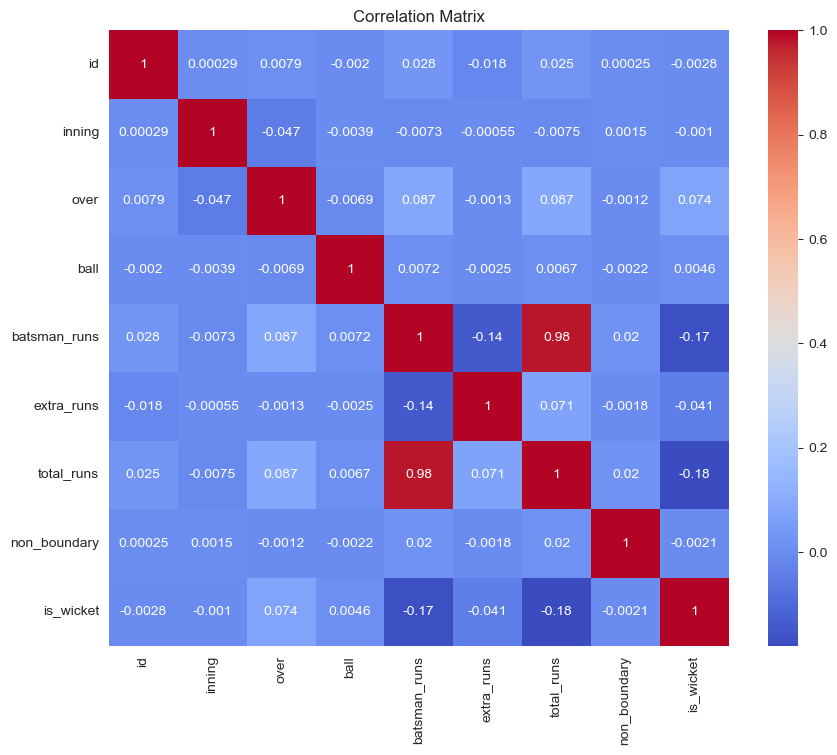

In [19]:
corr = deliveries.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Insight:
### Correlation identifies relationships
### among numerical variables.

# =====================================================

# BOXPLOT FOR OUTLIER DETECTION

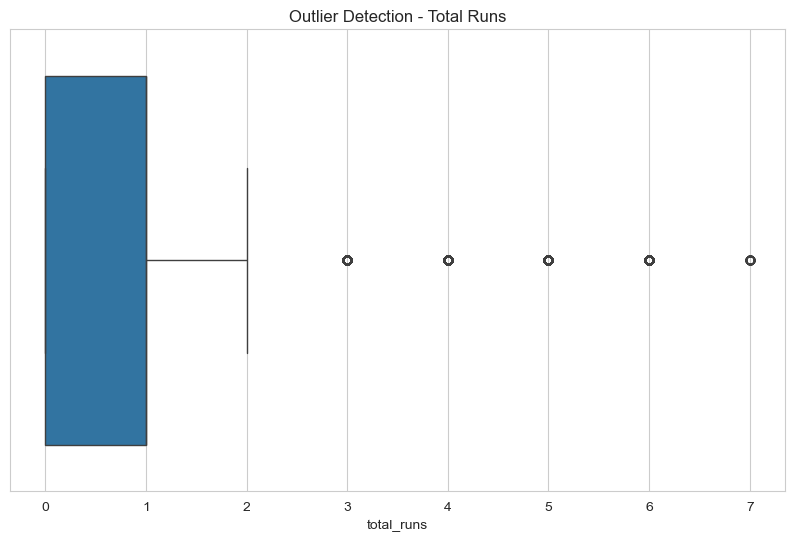

In [20]:

plt.figure(figsize=(10,6))
sns.boxplot(x=deliveries["total_runs"])
plt.title("Outlier Detection - Total Runs")
plt.show()



### Insight:
### Extreme scoring deliveries appear
### as outliers in the dataset.

# =====================================================

# SEASON WISE MATCHES

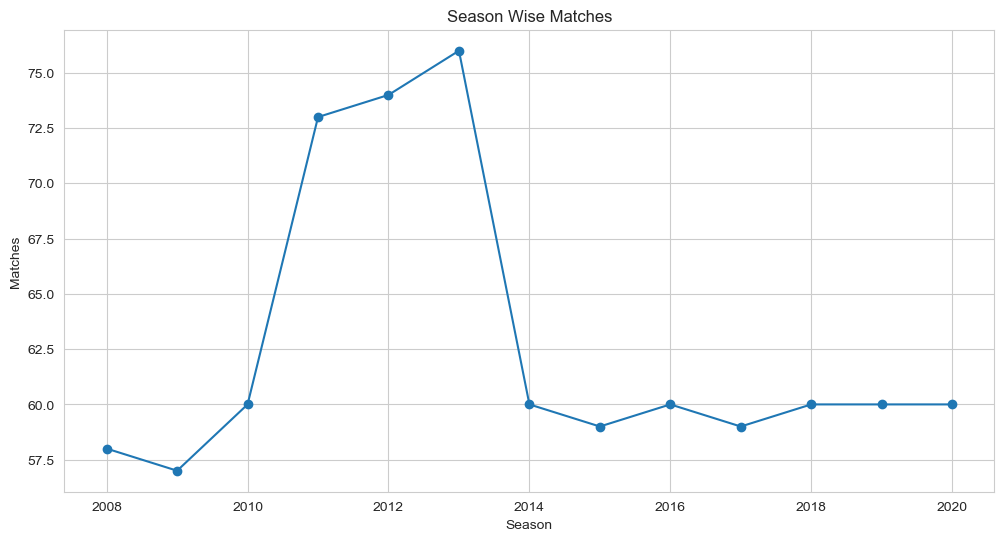

In [21]:
matches["season"] = pd.to_datetime(matches["date"]).dt.year

season_matches = matches["season"].value_counts().sort_index()

plt.figure(figsize=(12,6))
season_matches.plot(marker="o")
plt.title("Season Wise Matches")
plt.xlabel("Season")
plt.ylabel("Matches")
plt.show()


### Insight:
### IPL match volume varies by season.

# =====================================================

# KEY FINDINGS & BUSINESS INSIGHTS

In [22]:
print("\n" + "="*60)
print("KEY FINDINGS & BUSINESS INSIGHTS")
print("="*60)

print("""
1. The run distribution analysis showed that most deliveries resulted in
   0–1 runs, indicating that singles and dot balls play a crucial role
   in building an innings.

2. The top-performing batsmen consistently contributed a significant
   portion of their team's total runs, highlighting the importance of
   experienced batters in match outcomes.

3. Wicket-taking bowlers had a major impact on controlling the flow of runs
   and changing the momentum of matches.

4. Analysis of match results revealed that a small number of franchises
   achieved higher win counts, demonstrating long-term consistency and
   effective team management.

5. Toss-winning teams gained a competitive advantage in several matches,
   although match victory depended on overall team performance rather than
   the toss result alone.

6. Venue analysis indicated that certain stadiums hosted a larger number
   of matches, making them key locations in IPL history.

7. Correlation analysis helped identify relationships among numerical
   variables and provided insights into scoring patterns within matches.

8. Outlier detection revealed rare high-scoring deliveries, which often
   had a significant influence on match momentum and final results.
""")


KEY FINDINGS & BUSINESS INSIGHTS

1. The run distribution analysis showed that most deliveries resulted in
   0–1 runs, indicating that singles and dot balls play a crucial role
   in building an innings.

2. The top-performing batsmen consistently contributed a significant
   portion of their team's total runs, highlighting the importance of
   experienced batters in match outcomes.

3. Wicket-taking bowlers had a major impact on controlling the flow of runs
   and changing the momentum of matches.

4. Analysis of match results revealed that a small number of franchises
   achieved higher win counts, demonstrating long-term consistency and
   effective team management.

5. Toss-winning teams gained a competitive advantage in several matches,
   although match victory depended on overall team performance rather than
   the toss result alone.

6. Venue analysis indicated that certain stadiums hosted a larger number
   of matches, making them key locations in IPL history.

7. Correlatio

In [23]:
# =====================================================

# PROJECT CONCLUSION

In [24]:

print("\n" + "="*60)
print("PROJECT CONCLUSION")
print("="*60)

print("""
1. Identified top batsmen and bowlers.
2. Analyzed team performance.
3. Measured toss impact on match results.
4. Explored venue-wise trends.
5. Examined player performance.
6. Applied descriptive statistics.
7. Conducted correlation analysis.
8. Detected outliers.
9. Visualized IPL trends using charts.
10. Generated business insights from sports data.
""")

print("IPL Statistics Analysis Completed Successfully")


PROJECT CONCLUSION

1. Identified top batsmen and bowlers.
2. Analyzed team performance.
3. Measured toss impact on match results.
4. Explored venue-wise trends.
5. Examined player performance.
6. Applied descriptive statistics.
7. Conducted correlation analysis.
8. Detected outliers.
9. Visualized IPL trends using charts.
10. Generated business insights from sports data.

IPL Statistics Analysis Completed Successfully


# Final Conclusion

## This project conducted a comprehensive statistical analysis of IPL match and ball-by-ball data using Python, Pandas, NumPy, Matplotlib, and Seaborn. The study explored player performance, team success rates, toss impact, venue trends, scoring distributions, and relationships among key numerical variables. The findings demonstrated how data-driven analysis can be used to evaluate player contributions, identify winning patterns, and generate meaningful insights from sports data. This project showcases practical skills in data cleaning, exploratory data analysis (EDA), statistical analysis, and data visualization.